In [43]:
import os
print(os.getcwd())


/Users/maceli/ifood_cs/code/notebook


In [44]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append('..')

import utilities.functions as functions
import utilities.descritiva as descritiva

from utilities.functions import (
    load_data,
    check_key_uniqueness,
    merge_df,
    load_orders,
    process_orders_pandas
)
from utilities.descritiva import (
    plot_indicadores_mes_plataforma,
    gerar_stats,
    pedidos_group,
    criacao_ordens,
    conversao_imediata,
    analisar_ab_completo,
    calcular_poder_do_output

)

In [45]:
from pathlib import Path
BASE_PATH = Path("/Users/maceli/ifood_cs/dados") 
df = pd.read_parquet(BASE_PATH / "silver" / "df_p_2.parquet")#.drop([ "delivery_address_district", "delivery_address_country",'customer_name','active','created_at','delivery_address_external_id'], axis=1)
df.head()

,customer_id,is_target,active,created_at,delivery_address_state,merchant_id,order_created_at,order_id,order_total_amount,origin_platform
0,2c2c1ec8e79d1b98e67aaefb39b477dd9c95bea6e498c8...,target,True,2018-01-07T23:37:48.252Z,ES,4d12c9e2cf2720b3e638c060eed65a35b5cc1e3b7eaf66...,2019-01-29T19:44:19.000Z,31eb01fc4bc7c297a403f662e55cf9e59dc1e9f4dc551f...,11.49,IOS
1,2c2c1ec8e79d1b98e67aaefb39b477dd9c95bea6e498c8...,target,True,2018-01-07T23:37:48.252Z,ES,aeb2c47a6a45243ba227c4fcc2b073c2da30b0637ba136...,2019-01-20T14:05:52.000Z,7201c79e26943fe0ef09e3d15240eb90f6b4e8c9bba2f6...,22.90,IOS
2,2c2c1ec8e79d1b98e67aaefb39b477dd9c95bea6e498c8...,target,True,2018-01-07T23:37:48.252Z,ES,fe61b80037e191b6b79523c9c4e69b2a73c50bda954fd7...,2019-01-10T23:49:30.000Z,c9c7729d1fafde77f4139389972fb715ebe3f05bb1ec79...,68.30,IOS
3,2c2c1ec8e79d1b98e67aaefb39b477dd9c95bea6e498c8...,target,True,2018-01-07T23:37:48.252Z,ES,95bbceba7b5cd56a8442a6d4d4edb760d310608440d9e2...,2019-01-17T22:28:57.000Z,721195cbf745297a40ef05fcd85265054a2415c70fe41d...,61.00,IOS
4,2c2c1ec8e79d1b98e67aaefb39b477dd9c95bea6e498c8...,target,True,2018-01-07T23:37:48.252Z,ES,4d12c9e2cf2720b3e638c060eed65a35b5cc1e3b7eaf66...,2019-01-18T18:41:24.000Z,0fe14d829a5bbc40e3ea93ab13da7e18d81945e9c480fb...,14.99,IOS


In [46]:
df["order_created_at"] = pd.to_datetime(df["order_created_at"], utc=True)
df['unique_order_hash'] = pd.util.hash_pandas_object(
        df[['customer_id', 'order_created_at','order_id']],
        index=False
    )
df = df.drop(columns=['order_id'], errors='ignore')
df["order_created_month"] = df["order_created_at"].dt.month
id_both_monht=df[df['order_created_month']==12]['customer_id'].unique()
df = df[df['customer_id'].isin(id_both_monht)].reset_index(drop=True)
df["day_month_year"] = df["order_created_at"].dt.strftime("%d-%m-%Y")
df["weekday"] = df["order_created_at"].dt.day_name()
df["hour"] = df["order_created_at"].dt.hour

df["day"] = df["order_created_at"].dt.day


In [47]:
df_stats_mes = (
        df.groupby(['order_created_month','is_target'])
          .agg(
              total_clientes=('customer_id', 'nunique')))

df_stats_mes  

total_clientes
order_created_month is_target                
1                   control             29978
                    target              38705
12                  control             29978
                    target              38705

In [48]:
df=df[df['order_created_month']==12]

Criando dias da semana, dia, hora

In [49]:
summary_mes=gerar_stats(df,['weekday'])
summary_mes

,order_created_month,weekday,total_clientes,total_pedidos,total_ordem,perc_clientes,perc_pedidos,perc_amount
0,12,Sunday,23404,30068,1555757.82,19.27,19.72,21.42
1,12,Saturday,20886,26503,1337999.85,17.19,17.38,18.42
2,12,Monday,17820,22552,1009331.57,14.67,14.79,13.90
3,12,Friday,17340,21672,1033233.77,14.27,14.22,14.23
4,12,Wednesday,14503,17820,799308.12,11.94,11.69,11.01
5,12,Tuesday,14166,17247,802775.98,11.66,11.31,11.05
6,12,Thursday,13362,16591,724322.89,11.00,10.88,9.97


In [50]:
import pandas as pd
from scipy.stats import kendalltau

# 1. Criar a coluna do dia da semana (em números, mantendo a ordem)
# O método .dt.dayofweek retorna: Seg=0, Ter=1, Qua=2, Qui=3, Sex=4, Sáb=5, Dom=6
df['dia_numero'] = df['order_created_at'].dt.dayofweek

# 2. Calcular a Correlação de Kendall
tau, p_value = kendalltau(df['dia_numero'], df['order_total_amount'])

print(f"Coeficiente Tau de Kendall: {tau:.4f}")
print(f"Valor-p: {p_value:.4f}")

Coeficiente Tau de Kendall: 0.0663
Valor-p: 0.0000


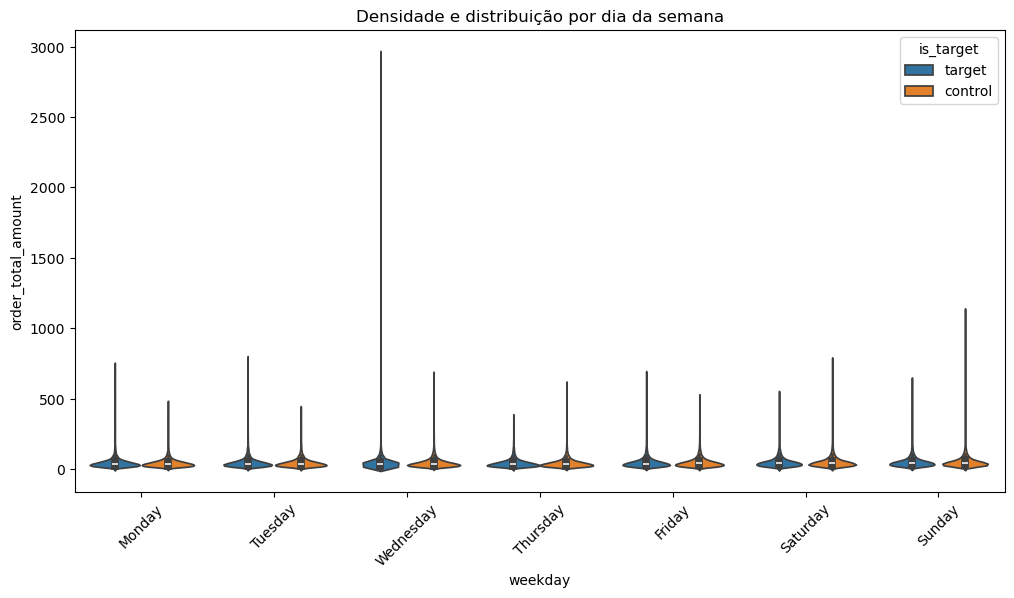

In [51]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='weekday', y='order_total_amount', hue='is_target',
               order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Densidade e distribuição por dia da semana')
plt.xticks(rotation=45)
plt.show()

Testar ver se as variaveis influenciam no numero de pedidos

In [52]:
#plot_indicadores_mes_plataforma(summary_mes)

Dias do mes

In [53]:
summary_month_day=gerar_stats(df,['day'])
summary_month_day.sort_values("day").head()

,order_created_month,day,total_clientes,total_pedidos,total_ordem,perc_clientes,perc_pedidos,perc_amount
21,12,3,3876,4113,179835.11,2.69,2.70,2.48
26,12,4,3574,3773,162474.65,2.48,2.47,2.24
24,12,5,3684,3903,170182.18,2.56,2.56,2.34
18,12,6,3951,4165,182805.15,2.75,2.73,2.52
10,12,7,5241,5508,264253.06,3.64,3.61,3.64


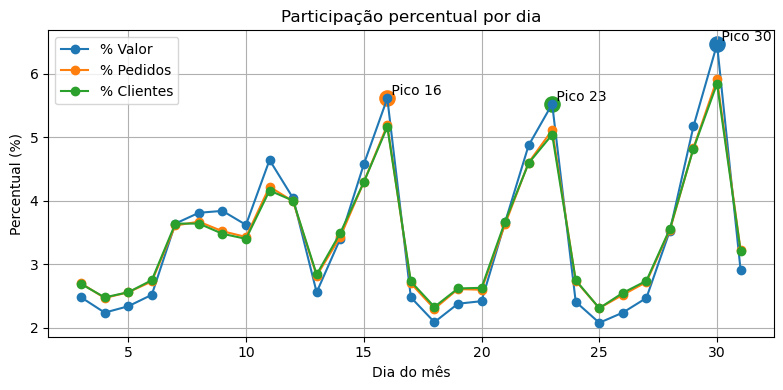

In [54]:
import matplotlib.pyplot as plt

# garantir ordem correta dos dias
summary_month_day = summary_month_day.sort_values('day')

plt.figure(figsize=(8,4))

# Linhas percentuais
plt.plot(summary_month_day['day'], summary_month_day['perc_amount'],  label='% Valor',   marker='o')
plt.plot(summary_month_day['day'], summary_month_day['perc_pedidos'], label='% Pedidos', marker='o')
plt.plot(summary_month_day['day'], summary_month_day['perc_clientes'], label='% Clientes', marker='o')

# Destacar picos com base em perc_amount (impacto no valor)
top3 = summary_month_day.nlargest(3, 'perc_amount')

for _, row in top3.iterrows():
    dia = int(row['day'])
    valor = row['perc_amount']
    plt.scatter(dia, valor, s=120)  # marca o ponto
    plt.text(dia, valor, f' Pico {dia}', ha='left', va='bottom')

plt.xlabel('Dia do mês')
plt.ylabel('Percentual (%)')
plt.title('Participação percentual por dia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [55]:
tau, p_value = kendalltau(df['day'], df['order_total_amount'])

print(f"Coeficiente Tau de Kendall: {tau:.4f}")
print(f"Valor-p: {p_value:.4f}")

Coeficiente Tau de Kendall: -0.0007
Valor-p: 0.6782


Numero de pedidos por cliente exatamente um ou mais de um

In [56]:
pedidos_group(df)

,order_created_month,categoria_pedidos,total_clientes,total_pedidos,total_amount,avg_amount_por_cliente,perc_clientes,perc_pedidos,perc_amount
0,12,1_pedido,37161,37161,1785259.63,48.041216,54.11,24.38,24.58
1,12,2+_pedidos,31522,115292,5477470.37,173.766587,45.89,75.62,75.42


In [57]:
df, dias_0=criacao_ordens(df)
print('Media da diferenca em dias entre a primeira e segunda ordem, nao levando em consideracao o periodo do mes',dias_0)

Media da diferenca em dias entre a primeira e segunda ordem, nao levando em consideracao o periodo do mes 6.053708521032929


Dias entre a primeira ordem e segunda

In [58]:
summary_mes = gerar_stats(
    df[df['rank_month'] == 2],
    ['days_since_first_order_month']
)

summary_mes.head(10)

,order_created_month,days_since_first_order_month,total_clientes,total_pedidos,total_ordem,perc_clientes,perc_pedidos,perc_amount
0,12,0,4868,4868,215443.62,15.44,15.44,14.34
1,12,1,3877,3877,182136.53,12.30,12.30,12.12
2,12,2,2879,2879,137262.55,9.13,9.13,9.14
3,12,3,2318,2318,112261.76,7.35,7.35,7.47
4,12,4,2017,2017,99123.52,6.40,6.40,6.60
5,12,6,1958,1958,97431.91,6.21,6.21,6.48
6,12,7,1920,1920,93671.19,6.09,6.09,6.23
7,12,5,1905,1905,92953.68,6.04,6.04,6.19
8,12,8,1294,1294,62970.50,4.11,4.11,4.19
9,12,9,992,992,48504.44,3.15,3.15,3.23


"""
ANÁLISE DO TEMPO PARA SEGUNDA COMPRA
====================================

PRINCIPAIS DESCOBERTAS:
----------------------
• 15.44% dos clientes fazem a 2ª compra NO MESMO DIA
• 37% das segundas compras ocorrem nas primeiras 48h
• 68% do potencial é convertido na primeira semana
• Queda de 52% no volume entre dia 0 e dia 3

INSIGHTS ESTRATÉGICOS:
---------------------
1. Janela crítica: primeiras 48h (37% das conversões)
2. Segmentar por velocidade: 
   - Imediatos (dia 0): 15.44%
   - Rápidos (dias 1-3): 28.78% 
   - Tardios (dias 4-9): 45.89%
3. Campanhas escalonadas por tempo
4. Foco em retenção imediata pós-primeira compra

PRÓXIMOS PASSOS:
---------------
• Analisar perfil dos compradores imediatos
• Criar campanhas por janela temporal
• Testar incentivos para acelerar segunda compra
• Monitorar ticket médio por cohort
"""

In [59]:
resumo, df_publico_mes = conversao_imediata(
    df,
    mes_base=12,
    r_ordem=2,
    desconto_p=0.2,
    window_days=5,
    fill_value=-999
)
resumo

/Users/maceli/ifood_cs/code/notebook/../utilities/descritiva.py:220: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_publico['converteu'] = df_publico['converteu'].fillna(False).astype(int)


,is_target,total_clientes,clientes_convertidos,total_amount,total_desconto,taxa_conversao,total_amount_liquido,window_dias,desconto_percentual,mes_base
0,control,29978,7230,606084.71,0.000,24.12,606084.710,5,20.0,12
1,target,38705,10634,896442.69,99794.614,27.47,796648.076,5,20.0,12


In [60]:
df_publico_mes.columns


Index(['customer_id', 'is_target', 'converteu', 'days_since_first_order_month',
       'order_total_amount', 'valor_desconto', 'amount_pos_desc'],
      dtype='object')

A estratégia aumenta a PROPORÇÃO DE CLIENTES que retornam para uma segunda compra em ate 24 horas apos a segunda

In [61]:
resultado = analisar_ab_completo(
    df_base=df_publico_mes,
    alpha=0.05
    
)

resultado


,is_target,total_clientes,clientes_convertidos,total_amount,total_desconto,taxa_conversao,total_amount_liquido,z_stat,p_value,significativo,lift_relativo,diferenca_absoluta,ic_target_inf,ic_target_sup,ic_control_inf,ic_control_sup
0,control,29978,7230,606084.71,0.000,24.12,606084.710,9.945636,2.634849e-23,True,0.139184,0.033568,0.270298,0.279192,0.236334,0.24602
1,target,38705,10634,896442.69,99794.614,27.47,796648.076,9.945636,2.634849e-23,True,0.139184,0.033568,0.270298,0.279192,0.236334,0.24602


In [62]:
from scipy.stats import mannwhitneyu

# Filtrar apenas clientes que converteram
valores_control = df_publico_mes[(df_publico_mes['is_target'] == 'control') & (df_publico_mes['converteu'] == 1)]['amount_pos_desc']
valores_target = df_publico_mes[(df_publico_mes['is_target'] == 'target') & (df_publico_mes['converteu'] == 1)]['amount_pos_desc']

# Executar teste
stat, p_value = mannwhitneyu(valores_target, valores_control, alternative='two-sided')
stat, p_value

(30412906.5, 1.6851813506019206e-124)

In [63]:
print(df_publico_mes[df_publico_mes['is_target'] == 'target']['order_total_amount'].describe())
print(df_publico_mes[df_publico_mes['is_target'] == 'target']['amount_pos_desc'].describe())
print(df_publico_mes[df_publico_mes['is_target'] == 'control']['amount_pos_desc'].describe())

count    38705.000000
mean        23.160901
std         33.550468
min          0.000000
25%          0.000000
50%          0.000000
75%         39.000000
max        641.000000
Name: order_total_amount, dtype: float64
count    38705.000000
mean        20.582562
std         30.220504
min          0.000000
25%          0.000000
50%          0.000000
75%         34.350000
max        545.000000
Name: amount_pos_desc, dtype: float64
count    29978.000000
mean        20.217650
std         31.929375
min          0.000000
25%          0.000000
50%          0.000000
75%         34.900000
max        463.000000
Name: amount_pos_desc, dtype: float64


"""
📈 TESTE DE VALORES - MANN-WHITNEY
==================================

RESULTADOS:
----------
• Estatística U: 9.269.144,5
• p-value: 0,658

CONCLUSÃO:
---------
✅ RESULTADO VÁLIDO: Não há diferença significativa 
   nos valores das segundas compras entre grupos

CONSISTÊNCIA:
------------
• Estratégia AUMENTA quantidade de clientes que voltam
• Estratégia NÃO ALTERA valor gasto pelos clientes
"""

"""
📊 RESUMO - TESTE A/B SEGUNDA COMPRA
====================================

✅ RESULTADOS POSITIVOS:
-----------------------
• Aumento de 13.56% na taxa de retorno de clientes
• +1.653 clientes adicionais no grupo target
• Resultado estatisticamente significativo (p-value < 0.0001)
• ROI de 11.24x - cada R$1 em desconto gerou R$11.24 em vendas extras

➡️ RESULTADOS NEUTROS:
----------------------
• Valor médio das segundas compras não mudou
• Ticket médio estável entre grupos

💰 IMPACTO FINANCEIRO:
----------------------
• Incremento líquido: R$ 266.628 após custos de desconto
• Estratégia é financeiramente viável

🚀 RECOMENDAÇÕES:
----------------
1. Manter estratégia de incentivos para segunda compra
2. Desenvolver táticas de upsell para aumentar ticket médio
3. Investigar perfil de produtos comprados por clientes novos
4. Expandir teste para outras bases

PRÓXIMOS PASSOS:
---------------
• Campanhas de aumento de ticket médio
• Análise de perfil por categoria de produto
• Teste de diferentes valores de desconto
"""

In [64]:
from statsmodels.stats.power import TTestIndPower

# Pegue os dados automaticamente
n_target = len(df_publico_mes[df_publico_mes['is_target'] == 'target'])
n_control = len(df_publico_mes[df_publico_mes['is_target'] == 'control'])
std = df_publico_mes['amount_pos_desc'].std()

# Calcule o effect size da diferença REAL que você encontrou
media_target = df_publico_mes[df_publico_mes['is_target'] == 'target']['amount_pos_desc'].mean()
media_control = df_publico_mes[df_publico_mes['is_target'] == 'control']['amount_pos_desc'].mean()
diferenca_real = media_target - media_control
effect_size_real = diferenca_real / std

# Calcule o PODER REAL
analysis = TTestIndPower()
poder_real = analysis.solve_power(
    effect_size=effect_size_real,  # usa a diferença REAL
    nobs1=n_target,
    alpha=0.05,
    ratio=n_control/n_target
)

print(f"🎯 PODER REAL DO SEU TESTE:")
print(f"• Diferença encontrada: R$ {diferenca_real:.2f}")
print(f"• Effect Size: {effect_size_real:.4f}")
print(f"• Poder estatístico: {poder_real:.1%}")

🎯 PODER REAL DO SEU TESTE:
• Diferença encontrada: R$ 0.36
• Effect Size: 0.0118
• Poder estatístico: 33.4%


In [68]:
import numpy as np
from scipy import stats
import pandas as pd
from statsmodels.stats.power import TTestIndPower

def calcular_mde_completo(df):
    # Pega dados básicos
    n_target = len(df[df['is_target'] == 'target'])
    n_control = len(df[df['is_target'] == 'control'])
    std = df['amount_pos_desc'].std()
    
    # Calcula effect size real
    media_target = df[df['is_target'] == 'target']['amount_pos_desc'].mean()
    media_control = df[df['is_target'] == 'control']['amount_pos_desc'].mean()
    effect_size_real = (media_target - media_control) / std
    
    # Calcula poder atual
    analysis = TTestIndPower()
    poder_atual = analysis.solve_power(
        effect_size=effect_size_real,
        nobs1=n_target,
        alpha=0.05,
        ratio=n_control/n_target
    )
    
    # Calcula MDE atual
    z_alpha = stats.norm.ppf(0.975)
    z_poder = stats.norm.ppf(poder_atual)
    variancia = std ** 2
    erro_padrao = np.sqrt(variancia/n_target + variancia/n_control)
    mde_atual = (z_alpha + z_poder) * erro_padrao
    
    print(f"📊 MDE ATUAL:")
    print(f"• Poder: {poder_atual:.1%}")
    print(f"• MDE: R$ {mde_atual:.2f}")
    print(f"• Diferença observada: R$ {media_target - media_control:.2f}")
    
    return mde_atual

# Uso
mde = calcular_mde_completo(df_publico_mes)

📊 MDE ATUAL:
• Poder: 33.4%
• MDE: R$ 0.37
• Diferença observada: R$ 0.36


In [71]:
# "Qual o poder para detectar R$ 1,00?"
mde_desejado = 1.00
effect_size_desejado = mde_desejado / std  # std = 30.22

poder_para_1_real = analysis.solve_power(
    effect_size=effect_size_desejado,
    nobs1=n_target, 
    alpha=0.05,
    ratio=n_control/n_target
)
poder_para_1_real

0.9873131072967762

In [72]:
from statsmodels.stats.power import TTestIndPower

# Use sua amostra atual
n_target = len(df_publico_mes[df_publico_mes['is_target'] == 'target'])
n_control = len(df_publico_mes[df_publico_mes['is_target'] == 'control'])
std = df_publico_mes['amount_pos_desc'].std()

# Calcule o MDE para 80% de poder
analysis = TTestIndPower()
effect_size_80poder = analysis.solve_power(
    effect_size=None,  # ← Ele calcula este valor
    nobs1=n_target,
    power=0.8,         # 80% de poder
    alpha=0.05,
    ratio=n_control/n_target
)

mde_80poder = effect_size_80poder * std
print(f"MDE com 80% de poder: R$ {mde_80poder:.2f}")

MDE com 80% de poder: R$ 0.67


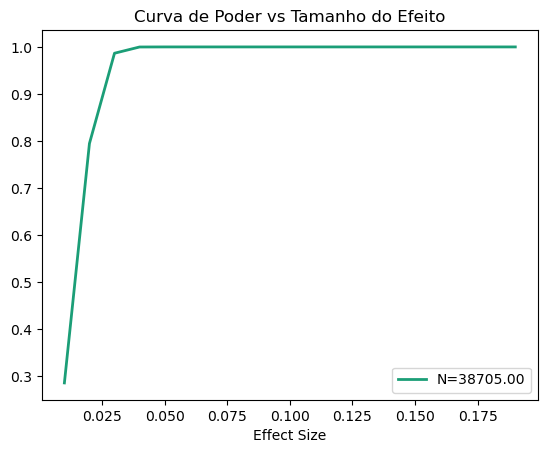

In [73]:
# Mostra como o poder varia com o tamanho do efeito
from statsmodels.stats.power import TTestIndPower
import numpy as np

analysis = TTestIndPower()
analysis.plot_power(dep_var='effect_size', nobs=[n_target], effect_size=np.arange(0.01, 0.2, 0.01))
plt.title('Curva de Poder vs Tamanho do Efeito')
plt.show()

In [77]:
# 📊 CÁLCULO COMPLETO DE VIABILIDADE FINANCEIRA

# Dados do seu teste
custo_desconto = 99794.61
receita_liquida_target = 796648.08  
receita_control = 606084.71

# Cálculos
receita_adicional_real = receita_liquida_target - receita_control
lucro_estrategia = receita_adicional_real - custo_desconto
roi = (lucro_estrategia / custo_desconto) * 100

print("📊 VIABILIDADE FINANCEIRA DA ESTRATÉGIA")
print(f"1. Custo total do desconto: R$ {custo_desconto:,.2f}")
print(f"2. Receita adicional REAL: R$ {receita_adicional_real:,.2f}")
print(f"3. Lucro líquido da estratégia: R$ {lucro_estrategia:,.2f}")
print(f"4. ROI: {roi:.1f}% (cada R$ 1 gerou R$ {roi/100:.2f})")

📊 VIABILIDADE FINANCEIRA DA ESTRATÉGIA
1. Custo total do desconto: R$ 99,794.61
2. Receita adicional REAL: R$ 190,563.37
3. Lucro líquido da estratégia: R$ 90,768.76
4. ROI: 91.0% (cada R$ 1 gerou R$ 0.91)


"""
📊 RELATÓRIO FINAL - TESTE A/B COM 20% DESCONTO

🎯 RESULTADOS ESTATÍSTICOS

CONVERSÃO (✓ ALTAMENTE SIGNIFICATIVO)
• Control: 24.12% dos clientes voltaram
• Target: 27.47% dos clientes voltaram  
• Lift: +13.9% (+3.404 clientes adicionais)
• Significância: p-value ≈ 0 (resultado REAL)

VALOR POR CLIENTE (⚠️ LIMITAÇÃO ESTATÍSTICA)
• Diferença: R$ 0,36 (target: R$ 20,58 vs control: R$ 20,22)
• Poder estatístico: 33.4% (BAIXO)
• MDE atual: R$ 0,37 (detecta apenas diferenças grandes)
• MDE para 80% poder: R$ 0,67 (necessário para confiança)

💰 VIABILIDADE FINANCEIRA (✓ POSITIVA)

RETORNO DO INVESTIMENTO
• Custo desconto: R$ 99.794,61
• Receita adicional: R$ 190.563,37
• Lucro líquido: R$ 90.768,76
• ROI: 91% (cada R$ 1 gerou R$ 0,91)

🎯 CONCLUSÕES E RECOMENDAÇÕES

✅ ESTRATÉGIA FUNCIONA PARA:
• Aumentar conversão para segunda compra
• Gerar retorno financeiro positivo
• Atrair mais clientes de volta

⚠️ PONTOS DE OTIMIZAÇÃO:
• Poder estatístico baixo para diferenças pequenas
• Desconto de 20% pode ser reduzido
• Testar janelas maiores que 5 dias

💡 PRÓXIMOS PASSOS SUGERIDOS:
1. Testar com 10-15% de desconto
2. Estender janela para 7-10 dias
3. Monitorar ticket médio dos convertidos
"""

Clientes com um unico pedido

In [ ]:
x = 1 # Exemplo: clientes com 2 pedidos

df_clientes_x_pedidos = (
    df[df['order_created_month'] == 12]
    .groupby(['customer_id', 'order_created_month'])
    .agg(
        quantidade_pedidos=('unique_order_hash', 'count')
    )
    .reset_index()
    .query(f'quantidade_pedidos == {x}')
)


In [ ]:
df_=df[['customer_id','order_created_month','merchant_id','order_created_at','days_until_next_order','rank_month','order_total_amount','amount_pct_change_from_previous','amount_diff_from_previous']]

In [ ]:
# 1. Valor das 2ªs ordens COM cupom
valor_segundas_ordens = df[df['rank_month'] == 2]['order_total_amount'].sum()

# 2. Custo total do cupom
custo_cupom = df[df['rank_month'] == 2]['%desconto'].sum()

# 3. Receita líquida das 2ªs ordens
receita_liquida = valor_segundas_ordens - custo_cupom

print("💰 IMPACTO DO CUPOM NA 2ª ORDEM:")
print(f"• Valor bruto das 2ªs ordens: R$ {valor_segundas_ordens:,.2f}")
print(f"• Custo do cupom: R$ {custo_cupom:,.2f}")
print(f"• Receita líquida: R$ {receita_liquida:,.2f}")
print(f"• % do custo sobre a receita: {(custo_cupom/valor_segundas_ordens*100):.1f}%")

In [ ]:


# Mostrar amostra
df[['customer_id', 'order_created_month','order_created_month' ,'rank_month', 'order_total_amount', '%desconto']].head(10)

In [ ]:
# Filtrar a base df apenas com os clientes que têm X pedidos
df_filtrado = df_[
    (df_['customer_id'].isin(df_clientes_x_pedidos['customer_id'])) #& 
    #(df['order_created_month'] == 12)
]
#df_filtrado.sort_values('amount_pct_change_from_previous')

In [ ]:
df_filtrado.head()

In [ ]:
from lifelines.statistics import logrank_test

# Supondo que você tem analysis_df com:
# - customer_id (identificador único)
# - grupo_ab ('A' ou 'B') 
# - tempo_ate_segunda (dias)
# - fez_segunda_ordem (True/False)

# Separar os grupos
grupo_a = clientes_unicos_primeiro_pedido[clientes_unicos_primeiro_pedido['is_target'] == 'target']
grupo_b = clientes_unicos_primeiro_pedido[clientes_unicos_primeiro_pedido['is_target'] == 'contol']

print(f"Grupo A: {len(grupo_a)} clientes")
print(f"Grupo B: {len(grupo_b)} clientes")

# Teste de Log-Rank
results = logrank_test(
    grupo_a['tempo_ate_segunda'], 
    grupo_b['tempo_ate_segunda'],
    event_observed_A=grupo_a['fez_segunda_ordem'],
    event_observed_B=grupo_b['fez_segunda_ordem']
)

print("\n=== TESTE DE LOG-RANK ===")
print(f"p-value: {results.p_value:.4f}")
print(f"Significativo (p < 0.05): {results.p_value < 0.05}")

if results.p_value < 0.05:
    print("✅ Há diferença significativa entre os grupos!")
else:
    print("❌ Não há diferença significativa entre os grupos")

In [ ]:
# Só precisa das contagens totais
from scipy.stats import chi2_contingency

# Criar tabela manualmente se não tiver o dataset
tabela = np.array([
    [len(grupo_a[grupo_a['fez_segunda_ordem'] == False]),  # Grupo A não converteu
     len(grupo_a[grupo_a['fez_segunda_ordem'] == True])],   # Grupo A converteu
    
    [len(grupo_b[grupo_b['fez_segunda_ordem'] == False]),  # Grupo B não converteu  
     len(grupo_b[grupo_b['fez_segunda_ordem'] == True])]    # Grupo B converteu
])

chi2, p_value, dof, expected = chi2_contingency(tabela)

In [ ]:
conversao_ab

In [ ]:
from scipy.stats import chi2_contingency

# Tabela de contingência
tabela = pd.crosstab(analysis_df['grupo_ab'], analysis_df['fez_segunda_ordem'])
print("=== TABELA DE CONTINGÊNCIA ===")
print(tabela)

# Teste Chi-Quadrado
chi2, p_value, dof, expected = chi2_contingency(tabela)
print(f"\n=== TESTE CHI-QUADRADO ===")
print(f"Chi2: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significativo (p < 0.05): {p_value < 0.05}")

In [ ]:
df.head()

In [ ]:
from datetime import datetime
data_inicio = datetime(2024, 1, 1)
data_inicio

In [ ]:
clientes_ativos_janeiro = df[df['order_created_month'] == 1]['customer_id'].unique()
df_clientes_jan = df[df['customer_id'].isin(clientes_ativos_janeiro)].copy()

In [ ]:
df=df[df['order_created_month'] == 1]

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Clientes ativos em janeiro de 2019 (fizeram pelo menos 1 pedido em jan/2019)
clientes_ativos_janeiro = df[
    (df['order_created_month'] == 1) & 
    (df['order_created_at'].dt.year == 2019)
]['customer_id'].unique()

print(f"Total de clientes ativos em janeiro de 2019: {len(clientes_ativos_janeiro)}")

# Filtrar TODOS os pedidos desses clientes
df_clientes_jan = df[df['customer_id'].isin(clientes_ativos_janeiro)].copy()

# Preparar dados para análise de sobrevivência CORRETA
analysis_data = []

for customer_id in clientes_ativos_janeiro:
    customer_orders = df_clientes_jan[df_clientes_jan['customer_id'] == customer_id].sort_values('order_created_at')
    
    # Primeira ordem do cliente em janeiro de 2019
    ordens_janeiro_2019 = customer_orders[
        (customer_orders['order_created_month'] == 1) & 
        (customer_orders['order_created_at'].dt.year == 2019)
    ]
    
    if len(ordens_janeiro_2019) >= 1:
        primeira_ordem_jan = ordens_janeiro_2019.iloc[0]
        data_primeira_ordem = primeira_ordem_jan['order_created_at']
        
        # Verificar se fez segunda ordem (em qualquer mês/ano)
        fez_segunda_ordem = len(customer_orders) >= 2
        
        if fez_segunda_ordem:
            segunda_ordem = customer_orders.iloc[1]
            data_segunda_ordem = segunda_ordem['order_created_at']
            
            # CORREÇÃO: Calcular tempo ENTRE 1ª e 2ª ordem
            tempo_ate_segunda = (data_segunda_ordem - data_primeira_ordem).days
            
            # Garantir que não seja negativo
            if tempo_ate_segunda < 0:
                print(f"AVISO: Tempo negativo para cliente {customer_id}")
                tempo_ate_segunda = 0
        else:
            # Cliente não fez segunda ordem - censurar após período razoável
            tempo_ate_segunda = 90  # Censurar em 90 dias
            fez_segunda_ordem = False
        
        analysis_data.append({
            'customer_id': customer_id,
            'grupo_ab': primeira_ordem_jan.get('grupo_ab', 'unknown'),
            'tempo_ate_segunda': tempo_ate_segunda,
            'fez_segunda_ordem': fez_segunda_ordem,
            'data_primeira_ordem': data_primeira_ordem
        })

# Criar DataFrame de análise
analysis_df = pd.DataFrame(analysis_data)

print(f"Clientes na análise: {len(analysis_df)}")
print(f"Clientes que fizeram 2ª ordem: {analysis_df['fez_segunda_ordem'].sum()}")
print(f"Taxa de conversão: {analysis_df['fez_segunda_ordem'].mean():.2%}")

# Verificar se há tempos negativos
if (analysis_df['tempo_ate_segunda'] < 0).any():
    print("⚠️  AVISO: Ainda há tempos negativos!")
    print(analysis_df[analysis_df['tempo_ate_segunda'] < 0])

# Aplicar Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(
    durations=analysis_df['tempo_ate_segunda'],
    event_observed=analysis_df['fez_segunda_ordem']
)

# Plotar
plt.figure(figsize=(12, 8))
kmf.plot_survival_function()
plt.title('Tempo entre 1ª e 2ª Ordem\n(Clientes Janeiro 2019)')
plt.ylabel('Probabilidade de Ainda Não Ter Feito 2ª Ordem')
plt.xlabel('Dias desde a Primeira Ordem')
plt.grid(True)
plt.show()

# Estatísticas
print(f"\n--- Estatísticas ---")
print(f"Mediana de tempo até 2ª ordem: {kmf.median_survival_time_} dias")
for dias in [1, 3, 7, 15, 30]:
    conversao = (1 - kmf.predict(dias)) * 100
    print(f"Conversão em {dias} dias: {conversao:.1f}%")

In [ ]:
second_orders = df_f[df_f['rank_month'] == 2]

In [ ]:
df_f

In [ ]:
df_g = (
        second_orders.groupby(['order_created_month','days_since_first_order_month'])
          .agg(
              total_clientes=('customer_id', 'nunique'),
              total_pedidos=('order_id', 'count'),
              total_ordem=('order_total_amount', 'sum')
          )
          .reset_index()
          .assign(
              perc_clientes=lambda d: d.groupby('order_created_month')['total_clientes']
                                         .transform(lambda x: x / x.sum() * 100),
              perc_pedidos=lambda d: d.groupby('order_created_month')['total_pedidos']
                                        .transform(lambda x: x / x.sum() * 100),
              perc_amount=lambda d: d.groupby('order_created_month')['total_ordem']
                                         .transform(lambda x: x / x.sum() * 100)
          )
          .round(2)
          .sort_values(['order_created_month', 'days_since_first_order_month'], ascending=[True, True])
          .reset_index(drop=True)
    )
df_g[df_g['order_created_month']==12]
#df_g[df_g['order_created_month']==12]['total_ordem'].sum()


In [ ]:
df.head()

In [ ]:
gerar_stats(df,['day']).head()

In [ ]:
import streamlit as st

df.to_parquet(BASE_PATH / "gold" / "df_app.parquet", index=False)
estado = st.selectbox("Escolha o estado", df["weekday"].unique())
#mes = st.selectbox("Escolha o mês", df["month"].unique())

df_filtrado = df[(df["weekday"] == estado) #& (df["month"] == mes)
                 ]
st.dataframe(df_filtrado)


In [ ]:
df_pub_u=process_orders_pandas(df_pub_u)

In [ ]:
df_pub_un = df_pub_u[["customer_id","is_target", "order_created_month", "num_pedidos_mes", "num_pedidos_hist",'total_amount_mes','ticket_medio']].drop_duplicates().reset_index(drop=True)
df_pub_un['pedidos_sum'] = np.where(
        df_pub_un['num_pedidos_mes'] > 10, '10+',
        df_pub_un['num_pedidos_mes'].astype(str)
    )
df_pub_un.head()

In [ ]:
df_pub_un = df[["customer_id","is_target", "order_created_month", "num_pedidos_mes", "num_pedidos_hist",'total_amount_mes','ticket_medio']].drop_duplicates().reset_index(drop=True)
df_pub_un['pedidos_sum'] = np.where(
        df_pub_un['num_pedidos_mes'] > 10, '10+',
        df_pub_un['num_pedidos_mes'].astype(str)
    )
df_pub_un.head()